In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from datasets import load_dataset
from qwen_vl_utils import process_vision_info

model_path = "Qwen/Qwen2.5-VL-7B-Instruct"
target_model = (
    Qwen2_5_VLForConditionalGeneration.from_pretrained(
        pretrained_model_name_or_path=model_path,
        torch_dtype=torch.bfloat16,
    )
    .eval()
    .cuda()
)
processor = AutoProcessor.from_pretrained(model_path, min_pixels=50176, max_pixels=802816)

/opt/conda/envs/sglang/lib/python3.11/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/opt/conda/envs/sglang/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 5/5 [00:00<00:00, 40.86it/s]
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class 

Processing samples:   4%|▍         | 101/2592 [00:20<08:23,  4.95it/s]



📊 统计结果：
样本总数: 101
总token数: 280350
总视觉token数: 198102
视觉token占比: 0.7066 (70.66%)
平均token数: 2775.7
中位数token数: 2785.0
90分位: 2927.0
95分位: 2967.0
最大token数: 3200
最小token数: 1669


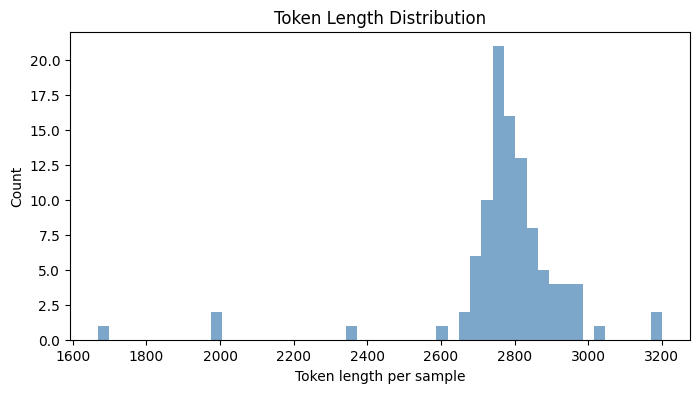

In [3]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
data_files = "/home/gulihui/workspace/dev_github/SpecForge/cache/dataset/test_kling_vl.jsonl"
train_dataset = load_dataset("json", data_files=data_files)["train"]


token_lengths = []
image_token_counts = []

total_image_tokens = 0
total_tokens = 0

for i in tqdm(range(len(train_dataset)), desc="Processing samples"):
    if i > 100:
        break
    messages = []
    for j, sentence in enumerate(train_dataset["conversations"][i]):
        role = sentence["role"]
        if role == "user" or role == "system":
            content = [
                {"type": "image", "image": train_dataset["image"][i]},
                {"type": "text", "text": sentence["content"]}
            ]
            messages.append({"role": role, "content": content})
        # else:
        #    messages.append({"role": role, "content": sentence["content"]})
    
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        return_tensors="pt",
        max_length=8192
    )

    n_image_tokens = (inputs["input_ids"] == target_model.model.config.image_token_id).sum().item()
    sum_tokens = inputs["input_ids"].shape[1]

    token_lengths.append(sum_tokens)
    image_token_counts.append(n_image_tokens)

    total_image_tokens += n_image_tokens
    total_tokens += sum_tokens

# --- 汇总统计 ---
token_lengths = np.array(token_lengths)
image_token_counts = np.array(image_token_counts)

image_token_ratio = total_image_tokens / total_tokens if total_tokens > 0 else 0

print("\n📊 统计结果：")
print(f"样本总数: {len(token_lengths)}")
print(f"总token数: {total_tokens}")
print(f"总视觉token数: {total_image_tokens}")
print(f"视觉token占比: {image_token_ratio:.4f} ({image_token_ratio*100:.2f}%)")
print(f"平均token数: {token_lengths.mean():.1f}")
print(f"中位数token数: {np.median(token_lengths):.1f}")
print(f"90分位: {np.percentile(token_lengths, 90):.1f}")
print(f"95分位: {np.percentile(token_lengths, 95):.1f}")
print(f"最大token数: {token_lengths.max()}")
print(f"最小token数: {token_lengths.min()}")

# --- 找出过长样本 ---
threshold = 8192
long_indices = np.where(token_lengths > threshold)[0]
if len(long_indices) > 0:
    print(f"\n⚠️ 共有 {len(long_indices)} 个样本超过 {threshold} tokens")
    print(f"这些样本的索引: {long_indices.tolist()[:20]} ...")  # 仅打印前20个
    print(f"对应长度: {[token_lengths[i] for i in long_indices[:20]]}")

# --- 可视化分布（可选） ---
plt.figure(figsize=(8, 4))
plt.hist(token_lengths, bins=50, color='steelblue', alpha=0.7)
plt.xlabel("Token length per sample")
plt.ylabel("Count")
plt.title("Token Length Distribution")
plt.show()